In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Importings


In [ ]:
# Install DeepMIMO
!pip install --pre deepmimo

# Import manual-wide dependencies
import os
import numpy as np
import deepmimo as dm
import matplotlib.pyplot as plt

import numpy as np
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.8/234.8 kB 5.2 MB/s eta 0:00:00


# Loading Deepmimo_scenario

In [ ]:
!unzip /content/boston_small_dm_export.zip -d /content/deepmimo_scenarios

Archive:  /content/boston_small_dm_export.zip
   creating: /content/deepmimo_scenarios/boston_small_export/
  inflating: /content/deepmimo_scenarios/__MACOSX/._boston_small_export  
  inflating: /content/deepmimo_scenarios/boston_small_export/tx_pos_t000_tx002_r001.npz  
  inflating: /content/deepmimo_scenarios/__MACOSX/boston_small_export/._tx_pos_t000_tx002_r001.npz  
  inflating: /content/deepmimo_scenarios/boston_small_export/tx_pos_t000_tx003_r001.npz  
  inflating: /content/deepmimo_scenarios/__MACOSX/boston_small_export/._tx_pos_t000_tx003_r001.npz  
  inflating: /content/deepmimo_scenarios/boston_small_export/aod_az_t000_tx000_r001.npz  
  inflating: /content/deepmimo_scenarios/__MACOSX/boston_small_export/._aod_az_t000_tx000_r001.npz  
  inflating: /content/deepmimo_scenarios/boston_small_export/aod_az_t000_tx001_r001.npz  
  inflating: /content/deepmimo_scenarios/__MACOSX/boston_small_export/._aod_az_t000_tx001_r001.npz  
  inflating: /content/deepmimo_scenarios/boston_small_

In [ ]:
dataset_dm_raw = dm.load("/content/deepmimo_scenarios/boston_small_export")

Loading TXRX PAIR: TXset 0 (tx_idx 0) & RXset 1 (rx_idxs 209764)
Loading TXRX PAIR: TXset 0 (tx_idx 1) & RXset 1 (rx_idxs 209764)
Loading TXRX PAIR: TXset 0 (tx_idx 2) & RXset 1 (rx_idxs 209764)
Loading TXRX PAIR: TXset 0 (tx_idx 3) & RXset 1 (rx_idxs 209764)
Loading TXRX PAIR: TXset 0 (tx_idx 4) & RXset 1 (rx_idxs 209764)


Elimininate the users that are in the buildings.

In [ ]:
tx_id = 2  # hangi TX'e göre filtrelemek istiyorsan

active_idxs = dataset_dm_raw[tx_id].get_active_idxs()

print(f"Total UEs: {dataset_dm_raw[tx_id].n_ue}")
print(f"Active for TX{tx_id}: {len(active_idxs)}")

dataset_dm = [
    dataset_dm_raw[t].subset(active_idxs)
    for t in range(len(dataset_dm_raw))
]

print("Users in the buildigns are eliminated")

Total UEs: 209764
Active for TX2: 127137
Users in the buildigns are eliminated


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


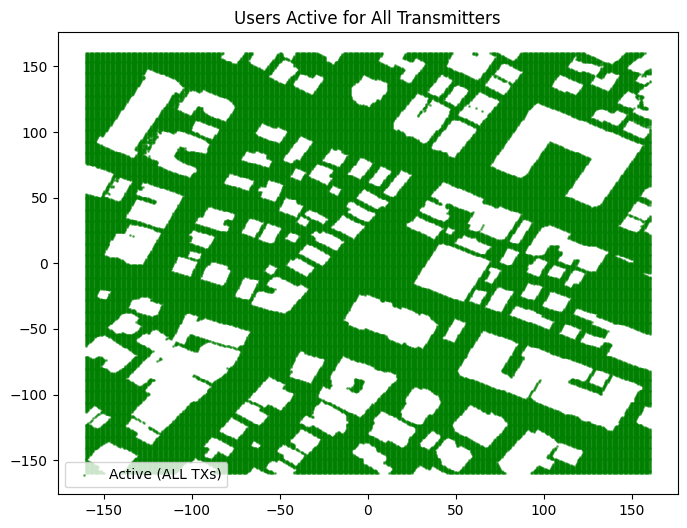

Active receivers (all TXs): 127137


In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(dataset_dm[0].rx_pos[:, 0],
            dataset_dm[0].rx_pos[:, 1],
            alpha=0.5, s=1, c='green',
            label='Active (ALL TXs)')

plt.legend()
plt.title("Users Active for All Transmitters")
plt.show()

print("Active receivers (all TXs):", dataset_dm[0].n_ue)

Removing inactive users to all transmitters

In [ ]:
# Eliminasyon öncesi RX pozisyonları ve index uzayı
rx_pos_all = dataset_dm[0].rx_pos.copy()
all_idxs = np.arange(rx_pos_all.shape[0])


In [ ]:
tx_ref = 2

# TX2 hariç diğer TX'lerin gördüğü UE'lerin birleşimi
active_others = set()
for t in range(len(dataset_dm)):
    if t == tx_ref:
        continue
    active_others |= set(dataset_dm[t].get_active_idxs())

active_others_idxs = np.array(sorted(active_others))

print(f"UEs seen by others: {len(active_others_idxs)}")

# SADECE buna göre mask'le
dataset_dm = [
    dataset_dm[t].subset(active_others_idxs)
    for t in range(len(dataset_dm))
]


UEs seen by others: 101637


In [ ]:
eliminated_idxs = np.setdiff1d(all_idxs, active_others_idxs)

print(f"Kept users      : {len(active_others_idxs)}")
print(f"Eliminated users: {len(eliminated_idxs)}")


Kept users      : 101637
Eliminated users: 25500


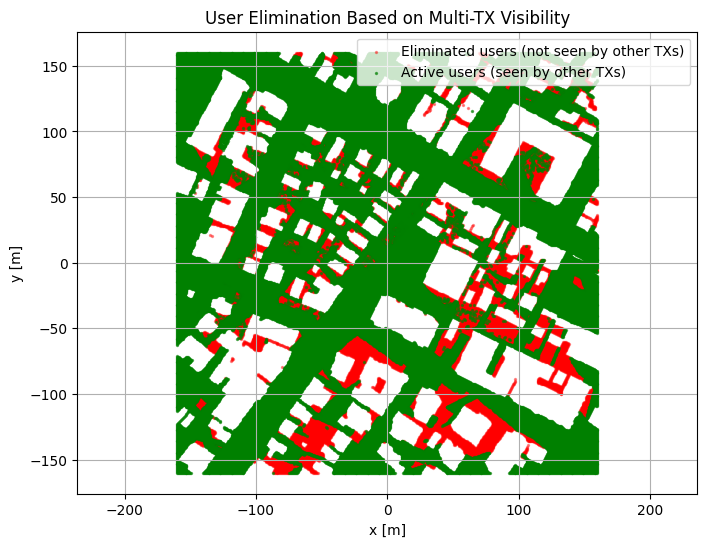

In [ ]:
plt.figure(figsize=(8, 6))

# 🔴 Elenen kullanıcılar
plt.scatter(
    rx_pos_all[eliminated_idxs, 0],
    rx_pos_all[eliminated_idxs, 1],
    c='red',
    s=2,
    alpha=0.4,
    label='Eliminated users (not seen by other TXs)'
)

# 🟢 Kalan kullanıcılar
plt.scatter(
    rx_pos_all[active_others_idxs, 0],
    rx_pos_all[active_others_idxs, 1],
    c='green',
    s=2,
    alpha=0.6,
    label='Active users (seen by other TXs)'
)

plt.legend()
plt.title("User Elimination Based on Multi-TX Visibility")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.axis("equal")
plt.grid(True)
plt.show()


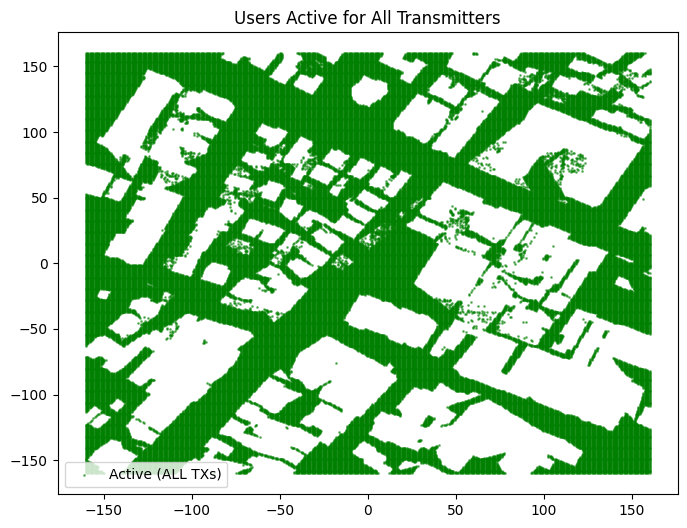

Active receivers (all TXs): 101637


In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(dataset_dm[0].rx_pos[:, 0],
            dataset_dm[0].rx_pos[:, 1],
            alpha=0.5, s=1, c='green',
            label='Active (ALL TXs)')

plt.legend()
plt.title("Users Active for All Transmitters")
plt.show()

print("Active receivers (all TXs):", dataset_dm[0].n_ue)

Delete the TX2 (Satelite TX) from the dataset

In [ ]:
tx_id = 2

# MacroDataset -> Python list
dataset_dm = [dataset_dm[i] for i in range(len(dataset_dm))]

# TX2'yi sil
dataset_dm.pop(tx_id)

print("TX_2 is extracted from the dataset_dm")
print("New length:", len(dataset_dm))
print("Indices now:", list(range(len(dataset_dm))))

TX_2 is extracted from the dataset_dm
New length: 4
Indices now: [0, 1, 2, 3]


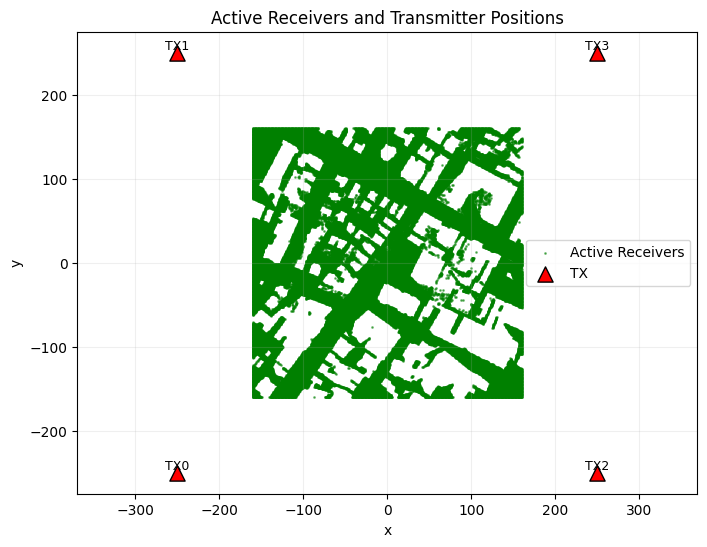

Active receivers (all TXs): 101637


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# RX'ler
plt.scatter(
    dataset_dm[0].rx_pos[:, 0],
    dataset_dm[0].rx_pos[:, 1],
    alpha=0.5,
    s=1,
    c='green',
    label='Active Receivers'
)

# TX'ler
for t in range(len(dataset_dm)):
    tx_x, tx_y = dataset_dm[t].tx_pos[0], dataset_dm[t].tx_pos[1]
    plt.scatter(
        tx_x, tx_y,
        c='red',
        s=120,
        marker='^',
        edgecolors='black',
        zorder=5,
        label='TX' if t == 0 else None  # legend'da bir kere görünsün
    )
    plt.text(
        tx_x, tx_y,
        f'TX{t}',
        fontsize=9,
        ha='center',
        va='bottom',
        color='black'
    )

plt.legend()
plt.title("Active Receivers and Transmitter Positions")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.2)
plt.axis('equal')
plt.show()

print("Active receivers (all TXs):", dataset_dm[0].n_ue)


Set default configurations


In [ ]:
# Create channel parameters with all options for TX0
#halfwave-dipole

BW = 400e6
ch_params_tx0 = dm.ChannelParameters()

# Antenna parameters

# Base station antenna parameters
ch_params_tx0.bs_antenna.radiation_pattern = "halfwave-dipole"

ch_params_tx0.bs_antenna.rotation = np.array([0, 45, 45])  # [az, el, pol] in degrees
ch_params_tx0.bs_antenna.fov = np.array([180, 90])      # [az, el] in degrees
ch_params_tx0.bs_antenna.shape = np.array([16, 16])        # [horizontal, vertical] elements
ch_params_tx0.bs_antenna.spacing = 0.5                   # Element spacing in wavelengths


# User equipment antenna parameters
ch_params_tx0.ue_antenna.rotation = np.array([0, 0, 0])  # [az, el, pol] in degrees
ch_params_tx0.ue_antenna.fov = np.array([360, 180])      # [az, el] in degrees
ch_params_tx0.ue_antenna.shape = np.array([1, 1])        # [horizontal, vertical] elements
ch_params_tx0.ue_antenna.spacing = 0.5                   # Element spacing in wavelengths

# Channel parameters
ch_params_tx0.freq_domain = True  # Whether to compute frequency domain channels
ch_params_tx0.num_paths = 50      # Number of paths
ch_params_tx0.doppler = False     # Whether to add Doppler to the channels

# OFDM parameters
ch_params_tx0.ofdm.bandwidth = BW                      # Bandwidth in Hz
ch_params_tx0.ofdm.subcarriers = 1024                     # Number of subcarriers
ch_params_tx0.ofdm.selected_subcarriers = np.arange(1)   # Which subcarriers to generate
ch_params_tx0.ofdm.rx_filter = 0                         # Receive Low Pass / ADC Filter

#------------------------------------------------------------------------------------------


# Create channel parameters with all options for TX1

ch_params_tx1 = dm.ChannelParameters()

# Antenna parameters

# Base station antenna parameters
ch_params_tx1.bs_antenna.radiation_pattern = "halfwave-dipole"

ch_params_tx1.bs_antenna.rotation = np.array([0, 45, -45])  # [az, el, pol] in degrees
ch_params_tx1.bs_antenna.fov = np.array([180, 90])      # [az, el] in degrees               does not work in v4 I think. We need direct   .fov.apply
ch_params_tx1.bs_antenna.shape = np.array([16, 16])        # [horizontal, vertical] elements
ch_params_tx1.bs_antenna.spacing = 0.5                   # Element spacing in wavelengths


# User equipment antenna parameters
ch_params_tx1.ue_antenna.rotation = np.array([0, 0, 0])  # [az, el, pol] in degrees
ch_params_tx1.ue_antenna.fov = np.array([360, 180])      # [az, el] in degrees
ch_params_tx1.ue_antenna.shape = np.array([1, 1])        # [horizontal, vertical] elements
ch_params_tx1.ue_antenna.spacing = 0.5                   # Element spacing in wavelengths

# Channel parameters
ch_params_tx1.freq_domain = True  # Whether to compute frequency domain channels
ch_params_tx1.num_paths = 50      # Number of paths
ch_params_tx1.doppler = False     # Whether to add Doppler to the channels

# OFDM parameters
ch_params_tx1.ofdm.bandwidth = BW                      # Bandwidth in Hz
ch_params_tx1.ofdm.subcarriers = 1024                     # Number of subcarriers
ch_params_tx1.ofdm.selected_subcarriers = np.arange(1)   # Which subcarriers to generate
ch_params_tx1.ofdm.rx_filter = 0


#------------------------------------------------------------------------------------------


# Create channel parameters with all options for TX2

ch_params_tx2 = dm.ChannelParameters()

# Antenna parameters

# Base station antenna parameters
ch_params_tx2.bs_antenna.radiation_pattern = "halfwave-dipole"

ch_params_tx2.bs_antenna.rotation = np.array([0,45,135])  # [az, el, pol] in degrees
ch_params_tx2.bs_antenna.fov = np.array([180, 90])      # [az, el] in degrees
ch_params_tx2.bs_antenna.shape = np.array([16, 16])        # [horizontal, vertical] elements
ch_params_tx2.bs_antenna.spacing = 0.5                   # Element spacing in wavelengths



# User equipment antenna parameters
ch_params_tx2.ue_antenna.rotation = np.array([0, 0, 0])  # [az, el, pol] in degrees
ch_params_tx2.ue_antenna.fov = np.array([360, 180])      # [az, el] in degrees
ch_params_tx2.ue_antenna.shape = np.array([1, 1])        # [horizontal, vertical] elements
ch_params_tx2.ue_antenna.spacing = 0.5                   # Element spacing in wavelengths

# Channel parameters
ch_params_tx2.freq_domain = True  # Whether to compute frequency domain channels
ch_params_tx2.num_paths = 50      # Number of paths
ch_params_tx2.doppler = False     # Whether to add Doppler to the channels

# OFDM parameters
ch_params_tx2.ofdm.bandwidth = BW                      # Bandwidth in Hz
ch_params_tx2.ofdm.subcarriers = 1024                     # Number of subcarriers
ch_params_tx2.ofdm.selected_subcarriers = np.arange(1)   # Which subcarriers to generate
ch_params_tx2.ofdm.rx_filter = 0

#------------------------------------------------------------------------------------------


# Create channel parameters with all options for TX2

ch_params_tx3 = dm.ChannelParameters()

# Antenna parameters

# Base station antenna parameters
ch_params_tx3.bs_antenna.radiation_pattern = "halfwave-dipole"

ch_params_tx3.bs_antenna.rotation = np.array([0,45,225])  # [az, el, pol] in degrees
ch_params_tx3.bs_antenna.fov = np.array([180, 90])      # [az, el] in degrees
ch_params_tx3.bs_antenna.shape = np.array([16, 16])        # [horizontal, vertical] elements
ch_params_tx3.bs_antenna.spacing = 0.5                   # Element spacing in wavelengths


# User equipment antenna parameters
ch_params_tx3.ue_antenna.rotation = np.array([0, 0, 0])  # [az, el, pol] in degrees
ch_params_tx3.ue_antenna.fov = np.array([360, 180])      # [az, el] in degrees
ch_params_tx3.ue_antenna.shape = np.array([1, 1])        # [horizontal, vertical] elements
ch_params_tx3.ue_antenna.spacing = 0.5                   # Element spacing in wavelengths

# Channel parameters
ch_params_tx3.freq_domain = True  # Whether to compute frequency domain channels
ch_params_tx3.num_paths = 50      # Number of paths
ch_params_tx3.doppler = False     # Whether to add Doppler to the channels

# OFDM parameters
ch_params_tx3.ofdm.bandwidth = BW                      # Bandwidth in Hz
ch_params_tx3.ofdm.subcarriers = 1024                     # Number of subcarriers
ch_params_tx3.ofdm.selected_subcarriers = np.arange(1)   # Which subcarriers to generate
ch_params_tx3.ofdm.rx_filter = 0

dataset_dm[0].apply_fov(bs_fov=[ 180, 90])
dataset_dm[1].apply_fov(bs_fov=[ 180, 90])
dataset_dm[2].apply_fov(bs_fov=[ 180, 90])
dataset_dm[3].apply_fov(bs_fov=[ 180, 90])



ch_params_list = []
ch_params_list.append(ch_params_tx0)
ch_params_list.append(ch_params_tx1)
ch_params_list.append(ch_params_tx2)
ch_params_list.append(ch_params_tx3)


base_rot_list = [
    ch_params_list[0].bs_antenna.rotation,   # TX0
    ch_params_list[1].bs_antenna.rotation,   # TX1
    ch_params_list[2].bs_antenna.rotation,   # TX2
    ch_params_list[3].bs_antenna.rotation,   # TX3
]

number_of_subcarriers = ch_params_tx3.ofdm.subcarriers
number_of_seleceted_subcarriers = len(ch_params_tx3.ofdm.selected_subcarriers )
N_sub = number_of_subcarriers/number_of_seleceted_subcarriers
num_antennas = np.square(ch_params_tx0.bs_antenna.shape[0])


Finding the out coverage threshold in terms of received power

In [ ]:
percentile_5_prx_dBm = -60

No doppler in channel generation because all velocities are zero


Generating channels: 100%|██████████| 101637/101637 [00:09<00:00, 11285.07it/s]


No doppler in channel generation because all velocities are zero


Generating channels: 100%|██████████| 101637/101637 [00:08<00:00, 11872.20it/s]


No doppler in channel generation because all velocities are zero


Generating channels: 100%|██████████| 101637/101637 [00:06<00:00, 15423.44it/s]


No doppler in channel generation because all velocities are zero


Generating channels: 100%|██████████| 101637/101637 [00:07<00:00, 13571.06it/s]


----------------------------------------------------------------------------------------------------
p5_prx_dBm =  -65.38 dBm


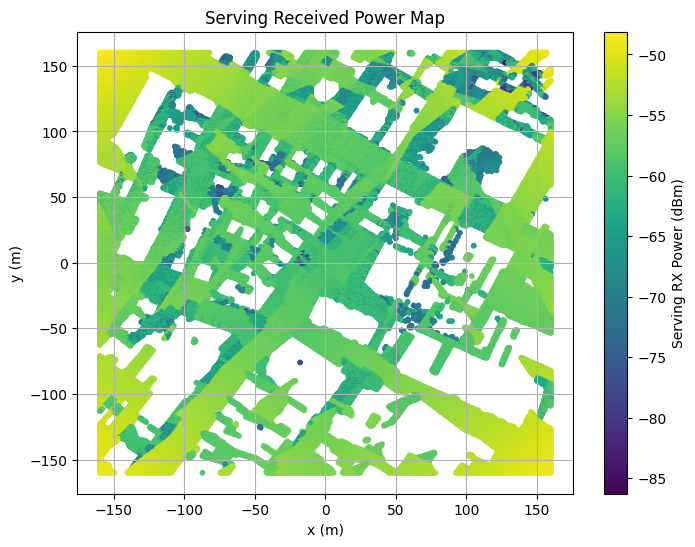

In [ ]:
def rx_power_dBm(H, P_tx_dBm):
    """
    P_tx_dBm: total BS transmit power (dBm)
    H: [num_ue, num_rx_ant, num_tx_ant, num_sc]
    """

    Nt  = H.shape[2] # num_tx_ant
    gain = np.sum(np.abs(H)**2, axis=(1,2,3)) * N_sub
    return P_tx_dBm + 10*np.log10(gain + 1e-30)



dataset_dm[0].compute_channels(ch_params_list[0])
dataset_dm[1].compute_channels(ch_params_list[1])
dataset_dm[2].compute_channels(ch_params_list[2])
dataset_dm[3].compute_channels(ch_params_list[3])


H0 = dataset_dm[0].channel
H1 = dataset_dm[1].channel
H2 = dataset_dm[2].channel
H3 = dataset_dm[3].channel

num_users = H0.shape[0]

# TX powers
P_tx_dBm_0 = 30
P_tx_dBm_1 = 30
P_tx_dBm_2 = 30
P_tx_dBm_3 = 30


# Received powers
Prx0_dBm = rx_power_dBm(H0, P_tx_dBm_0)
Prx1_dBm = rx_power_dBm(H1, P_tx_dBm_1)
Prx2_dBm = rx_power_dBm(H2, P_tx_dBm_2)
Prx3_dBm = rx_power_dBm(H3, P_tx_dBm_3)

Prx_all_dBm = np.stack([Prx0_dBm, Prx1_dBm, Prx2_dBm, Prx3_dBm], axis=1)

# Best cell
serving_bs = np.argmax(Prx_all_dBm, axis=1)

# Serving received power
Prx_serv_dBm = Prx_all_dBm[np.arange(num_users), serving_bs]

# Coverage threshold = 5th percentile of serving RX power
percentile_5_prx_dBm = np.percentile(Prx_serv_dBm, 5)

print("-"*100)
print(f"p5_prx_dBm = {percentile_5_prx_dBm:7.2f} dBm")

rx_pos = dataset_dm[0].rx_pos[:, :2]  # [num_users, 2]

plt.figure(figsize=(8,6))
sc = plt.scatter(
    rx_pos[:,0],
    rx_pos[:,1],
    c=Prx_serv_dBm,
    s=10,
    cmap="viridis"
)
plt.colorbar(sc, label="Serving RX Power (dBm)")
plt.title("Serving Received Power Map")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.grid(True)
plt.show()


# Config-level coverage plotting and KPI stats

No doppler in channel generation because all velocities are zero


Generating channels: 100%|██████████| 101637/101637 [00:08<00:00, 11490.62it/s]


No doppler in channel generation because all velocities are zero


Generating channels: 100%|██████████| 101637/101637 [00:07<00:00, 13475.03it/s]


No doppler in channel generation because all velocities are zero


Generating channels: 100%|██████████| 101637/101637 [00:07<00:00, 14500.13it/s]


No doppler in channel generation because all velocities are zero


Generating channels: 100%|██████████| 101637/101637 [00:08<00:00, 12435.66it/s]


Coverage: 88.17%  (89614/101637)


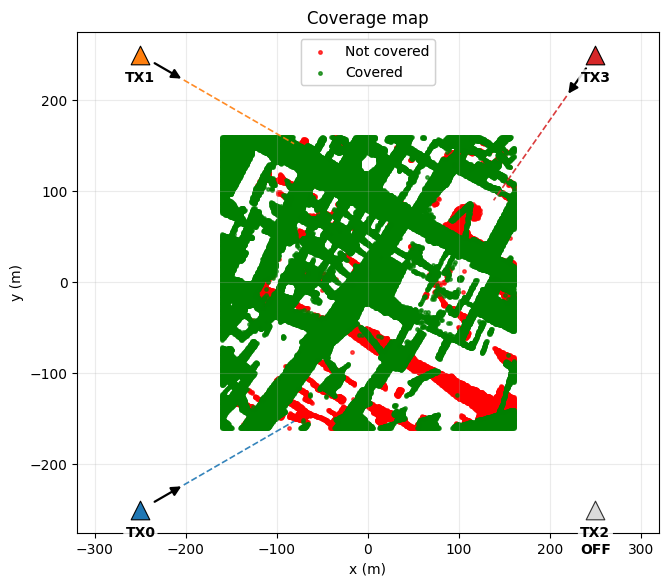

Power List: [43, 43, None, 43]
rx_power_coverage_ratio: 88.17%
SINR_mean: -0.2618285862246663
Prx_p5_dBm: -257.0
total_tx_power_watt: 59.85786944906639


In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch


def dBm_to_watt(P_tx_dBm: float) -> float:
    return 10 ** ((P_tx_dBm - 30.0) / 10.0)

def rx_power_dBm(H, P_tx_dBm):
    """
    P_tx_dBm: total BS transmit power (dBm)
    H: [num_ue, num_rx_ant, num_tx_ant, num_sc]
    """
    gain = np.sum(np.abs(H)**2, axis=(1,2,3)) * N_sub
    return float(P_tx_dBm) + 10*np.log10(gain + 1e-30)

def kpi_stats(x):
    x = np.asarray(x)
    return {
        "min": float(np.min(x)),
        "p5": float(np.percentile(x, 5)),
        "median": float(np.median(x)),
        "mean": float(np.mean(x)),
        "max": float(np.max(x)),
    }

def serving_percentages(serving_tx, n_tx=4):
    counts = np.bincount(np.asarray(serving_tx, dtype=int), minlength=n_tx)
    K = len(serving_tx)
    return 100.0 * counts / max(K, 1)

def coverage_ratio(powers, thr, direction="ge"):
    powers = np.asarray(powers)
    mask_valid = np.isfinite(powers)
    powers = powers[mask_valid]
    n_total = powers.size

    if direction == "ge":
        mask = (powers >= thr)
    elif direction == "gt":
        mask = (powers > thr)
    elif direction == "le":
        mask = (powers <= thr)
    elif direction == "lt":
        mask = (powers < thr)
    else:
        raise ValueError("direction must be one of: ge, gt, le, lt")

    n_cov = int(np.sum(mask))
    return n_cov / n_total, n_cov


def set_bs_rotation(ch_params, base_rot_deg_list, d_az=0.0, d_el=0.0, d_pol=0.0):
    """
    rotation = [pol, el, az] in degrees
    """
    base_rot_deg = np.asarray(base_rot_deg_list, dtype=float)
    new_rot = base_rot_deg + np.array([d_pol, d_el, d_az], dtype=float)
    ch_params.bs_antenna.rotation = new_rot


def compute_kpis_full_ues(
    dataset_full,
    P_tx_dBm_list,
    BW,
    NF_dB=7.0,
    N0_dBm_perHz=-174.0,
    active_tx_mask=None
):

    K = dataset_full[0].rx_pos.shape[0]

    if active_tx_mask is None:
        active_tx_mask = [True, True, True, True]
    active_tx_mask = np.asarray(active_tx_mask, dtype=bool)
    if not np.any(active_tx_mask):
        raise ValueError("All TXs are OFF. At least one TX must be active.")

    # noise (mW) over BW
    noise_dBm = N0_dBm_perHz + 10*np.log10(BW) + NF_dB
    noise_mW  = 10**(noise_dBm/10)

    H = [dataset_full[i].channel for i in range(4)]

    # Prx per TX (K,4)
    Prx_dBm = np.stack([rx_power_dBm(H[i], float(P_tx_dBm_list[i])) for i in range(4)], axis=1)

    # exclude OFF TX from association
    Prx_dBm[:, ~active_tx_mask] = -np.inf

    # linear powers (mW)
    Prx_mW = np.zeros_like(Prx_dBm, dtype=float)
    active_cols = np.where(active_tx_mask)[0]
    Prx_mW[:, active_cols] = 10**(Prx_dBm[:, active_cols]/10)

    # best-cell association
    serving_tx = np.argmax(Prx_dBm, axis=1)
    rx_power_serv_dBm = Prx_dBm[np.arange(K), serving_tx]

    # SINR
    sig = Prx_mW[np.arange(K), serving_tx]
    intf = np.sum(Prx_mW, axis=1) - sig
    sinr_lin = sig / (intf + noise_mW)
    SINR_dB = 10*np.log10(sinr_lin + 1e-30)

    # RSSI = signal + interference + noise
    rssi_mW = sig + intf + noise_mW
    RSSI_dBm = 10*np.log10(rssi_mW + 1e-30)

    # throughput (Shannon)
    thr_Mbps = (BW * np.log2(1 + sinr_lin)) / 1e6

    # RR equal sharing within each serving TX
    n_users_per_tx = np.bincount(serving_tx, minlength=Prx_mW.shape[1])
    share = 1.0 / np.maximum(n_users_per_tx[serving_tx], 1)
    thr_rr_Mbps = thr_Mbps * share

    return serving_tx, rx_power_serv_dBm, SINR_dB, thr_Mbps, thr_rr_Mbps, RSSI_dBm


def add_txs_with_beam_legend(
    ax,
    dataset_dm,
    base_rot_list,
    deltas_list,
    P_list_raw,
    arrow_len=35.0,
    beam_len=120.0,
    gap=12.0,
    marker_size=160,
    tx_colors=None,
    beam_style="--",
    tx_label_dy=-18,
):

    if tx_colors is None:
        tx_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

    for i in range(4):
        tx = np.array(dataset_dm[i].tx_pos).reshape(-1)
        tx_x, tx_y = float(tx[0]), float(tx[1])

        dAz, _ = deltas_list[i]
        P_val = P_list_raw[i]
        is_on = (P_val is not None)

        if is_on:
            face = tx_colors[i]
            label = f"TX{i}"
            alpha_marker = 1.0
        else:
            face = "lightgray"
            label = f"TX{i}\nOFF"
            alpha_marker = 0.8

        ax.scatter(
            tx_x, tx_y,
            s=marker_size,
            marker="^",
            facecolor=face,
            edgecolor="k",
            linewidth=0.8,
            alpha=alpha_marker,
            zorder=10
        )

        ax.text(
            tx_x, tx_y + tx_label_dy,
            label,
            ha="center",
            va="top",
            fontsize=10,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85),
            zorder=12
        )

        if not is_on:
            continue

        # yön: base_az + dAz
        base_az = float(np.asarray(base_rot_list[i], dtype=float)[2])
        az_dir_deg = base_az + float(dAz)

        th = np.deg2rad(az_dir_deg)
        ux, uy = np.cos(th), np.sin(th)

        x0 = tx_x + gap * ux
        y0 = tx_y + gap * uy
        x1 = tx_x + (gap + arrow_len) * ux
        y1 = tx_y + (gap + arrow_len) * uy

        arrow = FancyArrowPatch(
            (x0, y0), (x1, y1),
            arrowstyle="-|>",
            mutation_scale=14,
            linewidth=1.6,
            color="k",
            zorder=11
        )
        ax.add_patch(arrow)

        bx1 = x1 + beam_len * ux
        by1 = y1 + beam_len * uy
        ax.plot(
            [x1, bx1], [y1, by1],
            linestyle=beam_style,
            linewidth=1.2,
            color=tx_colors[i],
            alpha=0.9,
            zorder=9
        )


def build_config_row_from_arrays(
    active_tx_mask,
    total_tx_power_watt,
    P_list_raw,
    deltas_list,
    coverage_threshold_dBm,
    serving_tx,
    prx_serv_dBm,
    sinr_dB,
    thr_Mbps,
    thr_rr_Mbps,
    rssi_dBm
):
    rx_power_cov_ratio, rx_power_cov_n = coverage_ratio(prx_serv_dBm, coverage_threshold_dBm, "ge")
    K = len(prx_serv_dBm)
    rx_power_out_n = int(K - rx_power_cov_n)

    prx_s = kpi_stats(prx_serv_dBm)
    sinr_s = kpi_stats(sinr_dB)
    thr_s = kpi_stats(thr_Mbps)
    thr_rr_s = kpi_stats(thr_rr_Mbps)
    rssi_s = kpi_stats(rssi_dBm)

    serve_pct = serving_percentages(serving_tx, n_tx=4)

    row = {
        "tx0_on": bool(active_tx_mask[0]),
        "tx1_on": bool(active_tx_mask[1]),
        "tx2_on": bool(active_tx_mask[2]),
        "tx3_on": bool(active_tx_mask[3]),

        "total_tx_power_watt": float(total_tx_power_watt),

        "tx0_P_dBm": (-9999.0 if P_list_raw[0] is None else float(P_list_raw[0])),
        "tx1_P_dBm": (-9999.0 if P_list_raw[1] is None else float(P_list_raw[1])),
        "tx2_P_dBm": (-9999.0 if P_list_raw[2] is None else float(P_list_raw[2])),
        "tx3_P_dBm": (-9999.0 if P_list_raw[3] is None else float(P_list_raw[3])),

        "tx0_served_pct": float(serve_pct[0]),
        "tx1_served_pct": float(serve_pct[1]),
        "tx2_served_pct": float(serve_pct[2]),
        "tx3_served_pct": float(serve_pct[3]),

        "tx0_dAz": float(deltas_list[0][0]), "tx0_dEl": float(deltas_list[0][1]),
        "tx1_dAz": float(deltas_list[1][0]), "tx1_dEl": float(deltas_list[1][1]),
        "tx2_dAz": float(deltas_list[2][0]), "tx2_dEl": float(deltas_list[2][1]),
        "tx3_dAz": float(deltas_list[3][0]), "tx3_dEl": float(deltas_list[3][1]),

        "Prx_min_dBm": prx_s["min"],
        "Prx_p5_dBm": prx_s["p5"],
        "Prx_median_dBm": prx_s["median"],
        "Prx_mean_dBm": prx_s["mean"],
        "Prx_max_dBm": prx_s["max"],

        "SINR_min_dB": sinr_s["min"],
        "SINR_p5_dB": sinr_s["p5"],
        "SINR_median_dB": sinr_s["median"],
        "SINR_mean_dB": sinr_s["mean"],
        "SINR_max_dB": sinr_s["max"],

        "Thr_min_Mbps": thr_s["min"],
        "Thr_p5_Mbps": thr_s["p5"],
        "Thr_median_Mbps": thr_s["median"],
        "Thr_mean_Mbps": thr_s["mean"],
        "Thr_max_Mbps": thr_s["max"],

        "ThrRR_min_Mbps": thr_rr_s["min"],
        "ThrRR_p5_Mbps": thr_rr_s["p5"],
        "ThrRR_median_Mbps": thr_rr_s["median"],
        "ThrRR_mean_Mbps": thr_rr_s["mean"],
        "ThrRR_max_Mbps": thr_rr_s["max"],

        "RSSI_min_dBm": rssi_s["min"],
        "RSSI_p5_dBm": rssi_s["p5"],
        "RSSI_median_dBm": rssi_s["median"],
        "RSSI_mean_dBm": rssi_s["mean"],
        "RSSI_max_dBm": rssi_s["max"],

        "rx_power_thr_dBm": float(coverage_threshold_dBm),
        "rx_power_coverage_ratio": float(rx_power_cov_ratio),
        "rx_power_cov_n": int(rx_power_cov_n),
        "rx_power_out_n": int(rx_power_out_n),
    }
    return row


def plot_and_store_one_config(
    dataset_dm,
    ch_params_list,
    base_rot_list,
    deltas_list,
    P_list_raw,
    coverage_threshold_dBm,
    BW,
    NF_dB=7.0,
    N0_dBm_perHz=-174.0,
    s=6,
    save_dir=None,     # örn: "snapshots"
    tag=None,          # örn: "cfgA"  -> cfgA_config.parquet
):
    # active mask
    active_tx_mask = [p is not None for p in P_list_raw]
    if not any(active_tx_mask):
        raise ValueError("All TXs are OFF for this configuration.")

    # P list for KPI compute (dummy for OFF)
    P_list = [(-1000.0 if p is None else float(p)) for p in P_list_raw]
    total_tx_power_watt = float(sum(dBm_to_watt(p) for p in P_list))

    # 1) set rotations + compute channels
    for i in range(4):
        d_az, d_el = deltas_list[i]
        set_bs_rotation(ch_params_list[i], base_rot_list[i], d_az=d_az, d_el=d_el, d_pol=0.0)
        dataset_dm[i].compute_channels(ch_params_list[i])

    # 2) compute KPIs
    serving_tx, prx_serv_dBm, sinr_dB, thr_Mbps, thr_rr_Mbps, rssi_dBm = compute_kpis_full_ues(
        dataset_full=dataset_dm,
        P_tx_dBm_list=P_list,
        BW=BW,
        NF_dB=NF_dB,
        N0_dBm_perHz=N0_dBm_perHz,
        active_tx_mask=active_tx_mask
    )

    covered = prx_serv_dBm >= float(coverage_threshold_dBm)

    # receiver positions
    xy = dataset_dm[0].rx_pos[:, :2]
    x = xy[:, 0]
    y = xy[:, 1]

    n_cov = int(np.sum(covered))
    K = len(covered)
    covered_pct = 100 * n_cov / K
    print(f"Coverage: {covered_pct:.2f}%  ({n_cov}/{K})")

    # 3) plot
    fig, ax = plt.subplots(figsize=(7.5, 6.5))

    h_not = ax.scatter(x[~covered], y[~covered], s=s, c="red", alpha=0.7, label="Not covered")
    h_cov = ax.scatter(x[covered],  y[covered],  s=s, c="green", alpha=0.7, label="Covered")

    cov_leg = ax.legend(handles=[h_not, h_cov], loc="upper center")
    ax.add_artist(cov_leg)

    add_txs_with_beam_legend(
        ax=ax,
        dataset_dm=dataset_dm,
        base_rot_list=base_rot_list,
        deltas_list=deltas_list,
        P_list_raw=P_list_raw,
        arrow_len=40.0,
        beam_len=140,
        gap=15,
        marker_size=180
    )



#ax.set_title(f"Coverage map\nCoverage = {covered_pct:.2f}%")
    ax.set_title(f"Coverage map")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.axis("equal")
    ax.grid(True, alpha=0.25)
    plt.show()

    # 4) build config row (generator columns)
    config_row = build_config_row_from_arrays(
        active_tx_mask=active_tx_mask,
        total_tx_power_watt=total_tx_power_watt,
        P_list_raw=P_list_raw,
        deltas_list=deltas_list,
        coverage_threshold_dBm=float(coverage_threshold_dBm),
        serving_tx=serving_tx,
        prx_serv_dBm=prx_serv_dBm,
        sinr_dB=sinr_dB,
        thr_Mbps=thr_Mbps,
        thr_rr_Mbps=thr_rr_Mbps,
        rssi_dBm=rssi_dBm
    )

    # 5) save config parquet
    saved_path = None
    if save_dir is not None and tag is not None:
        os.makedirs(save_dir, exist_ok=True)
        saved_path = os.path.join(save_dir, f"{tag}_config.parquet")
        pd.DataFrame([config_row]).to_parquet(saved_path, index=False)


    return {
        "config_row": config_row,
        "saved_path": saved_path,
        "covered": covered,
        "serving_tx": serving_tx,
        "prx_serv_dBm": prx_serv_dBm,
        "sinr_dB": sinr_dB,
        "thr_Mbps": thr_Mbps,
        "thr_rr_Mbps": thr_rr_Mbps,
        "rssi_dBm": rssi_dBm
    }


# Example usage
#sıralama = [TX0, TX1, TX2, TX3]
#deltas_list = [(dAz,dEl)]
#P_list_raw  = [40, 40, None, 40]   None for off

deltas_list = [(-15,0), (15,0), (-10,0), (10,0)]
P_list_raw  = [43, 43, None, 43]
out = plot_and_store_one_config(
     dataset_dm=dataset_dm,
     ch_params_list=ch_params_list,
     base_rot_list=base_rot_list,
     deltas_list=deltas_list,
     P_list_raw=P_list_raw,
     coverage_threshold_dBm=-60,
     BW=BW,
     NF_dB=7.0,
     N0_dBm_perHz=-174.0,
     s=6,
     save_dir="snapshots",
     tag="cfgA"
 )
pd.DataFrame([out["config_row"]])
print(f"Power List: {P_list_raw}")
print(f"rx_power_coverage_ratio: {out['config_row']['rx_power_coverage_ratio']*100:.2f}%")
print(f"SINR_mean: {out["config_row"]["SINR_mean_dB"]}" )
print(f"Prx_p5_dBm: {out["config_row"]["Prx_p5_dBm"]}" )
print(f"total_tx_power_watt: {out["config_row"]["total_tx_power_watt"]}" )

No doppler in channel generation because all velocities are zero


Generating channels: 100%|██████████| 101637/101637 [00:09<00:00, 10805.23it/s]


No doppler in channel generation because all velocities are zero


Generating channels: 100%|██████████| 101637/101637 [00:13<00:00, 7680.30it/s] 


No doppler in channel generation because all velocities are zero


Generating channels: 100%|██████████| 101637/101637 [00:06<00:00, 15183.51it/s]


No doppler in channel generation because all velocities are zero


Generating channels: 100%|██████████| 101637/101637 [00:08<00:00, 12112.86it/s]


Coverage: 87.36%  (88786/101637)


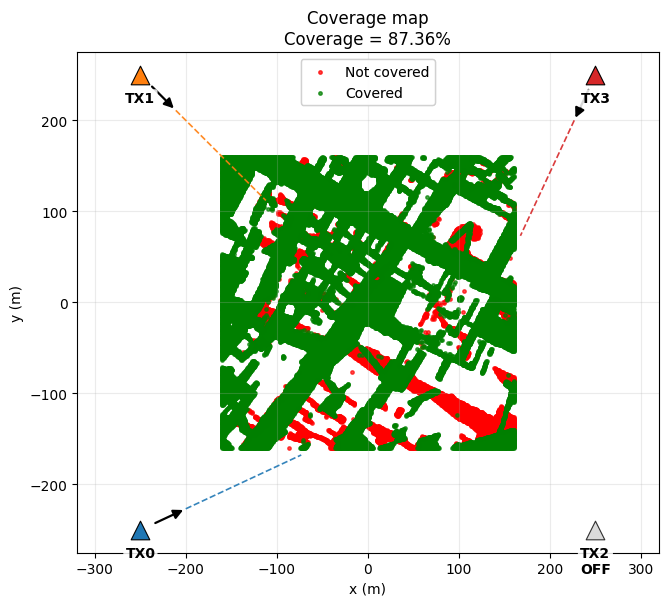

[OK] Saved config row -> snapshots/cfgA_config.parquet
Power List: [43, 43, None, 35]
rx_power_coverage_ratio: 87.36%
SINR_mean: 0.003049446690677845
Prx_p5_dBm: -257.0
total_tx_power_watt: 43.06752395954597


In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch


def dBm_to_watt(P_tx_dBm: float) -> float:
    return 10 ** ((P_tx_dBm - 30.0) / 10.0)

def rx_power_dBm(H, P_tx_dBm):
    """
    P_tx_dBm: total BS transmit power (dBm)
    H: [num_ue, num_rx_ant, num_tx_ant, num_sc]
    """
    gain = np.sum(np.abs(H)**2, axis=(1,2,3)) * N_sub
    return float(P_tx_dBm) + 10*np.log10(gain + 1e-30)

def kpi_stats(x):
    x = np.asarray(x)
    return {
        "min": float(np.min(x)),
        "p5": float(np.percentile(x, 5)),
        "median": float(np.median(x)),
        "mean": float(np.mean(x)),
        "max": float(np.max(x)),
    }

def serving_percentages(serving_tx, n_tx=4):
    counts = np.bincount(np.asarray(serving_tx, dtype=int), minlength=n_tx)
    K = len(serving_tx)
    return 100.0 * counts / max(K, 1)

def coverage_ratio(powers, thr, direction="ge"):
    powers = np.asarray(powers)
    mask_valid = np.isfinite(powers)
    powers = powers[mask_valid]
    n_total = powers.size

    if direction == "ge":
        mask = (powers >= thr)
    elif direction == "gt":
        mask = (powers > thr)
    elif direction == "le":
        mask = (powers <= thr)
    elif direction == "lt":
        mask = (powers < thr)
    else:
        raise ValueError("direction must be one of: ge, gt, le, lt")

    n_cov = int(np.sum(mask))
    return n_cov / n_total, n_cov


def set_bs_rotation(ch_params, base_rot_deg_list, d_az=0.0, d_el=0.0, d_pol=0.0):
    """
    rotation = [pol, el, az] in degrees
    """
    base_rot_deg = np.asarray(base_rot_deg_list, dtype=float)
    new_rot = base_rot_deg + np.array([d_pol, d_el, d_az], dtype=float)
    ch_params.bs_antenna.rotation = new_rot


def compute_kpis_full_ues(
    dataset_full,
    P_tx_dBm_list,
    BW,
    NF_dB=7.0,
    N0_dBm_perHz=-174.0,
    active_tx_mask=None
):

    K = dataset_full[0].rx_pos.shape[0]

    if active_tx_mask is None:
        active_tx_mask = [True, True, True, True]
    active_tx_mask = np.asarray(active_tx_mask, dtype=bool)
    if not np.any(active_tx_mask):
        raise ValueError("All TXs are OFF. At least one TX must be active.")

    # noise (mW) over BW
    noise_dBm = N0_dBm_perHz + 10*np.log10(BW) + NF_dB
    noise_mW  = 10**(noise_dBm/10)

    H = [dataset_full[i].channel for i in range(4)]

    # Prx per TX (K,4)
    Prx_dBm = np.stack([rx_power_dBm(H[i], float(P_tx_dBm_list[i])) for i in range(4)], axis=1)

    # exclude OFF TX from association
    Prx_dBm[:, ~active_tx_mask] = -np.inf

    # linear powers (mW)
    Prx_mW = np.zeros_like(Prx_dBm, dtype=float)
    active_cols = np.where(active_tx_mask)[0]
    Prx_mW[:, active_cols] = 10**(Prx_dBm[:, active_cols]/10)

    # best-cell association
    serving_tx = np.argmax(Prx_dBm, axis=1)
    rx_power_serv_dBm = Prx_dBm[np.arange(K), serving_tx]

    # SINR
    sig = Prx_mW[np.arange(K), serving_tx]
    intf = np.sum(Prx_mW, axis=1) - sig
    sinr_lin = sig / (intf + noise_mW)
    SINR_dB = 10*np.log10(sinr_lin + 1e-30)

    # RSSI = signal + interference + noise
    rssi_mW = sig + intf + noise_mW
    RSSI_dBm = 10*np.log10(rssi_mW + 1e-30)

    # throughput (Shannon)
    thr_Mbps = (BW * np.log2(1 + sinr_lin)) / 1e6

    # RR equal sharing within each serving TX
    n_users_per_tx = np.bincount(serving_tx, minlength=Prx_mW.shape[1])
    share = 1.0 / np.maximum(n_users_per_tx[serving_tx], 1)
    thr_rr_Mbps = thr_Mbps * share

    return serving_tx, rx_power_serv_dBm, SINR_dB, thr_Mbps, thr_rr_Mbps, RSSI_dBm


def add_txs_with_beam_legend(
    ax,
    dataset_dm,
    base_rot_list,
    deltas_list,
    P_list_raw,
    arrow_len=35.0,
    beam_len=120.0,
    gap=12.0,
    marker_size=160,
    tx_colors=None,
    beam_style="--",
    tx_label_dy=-18,
):

    if tx_colors is None:
        tx_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

    for i in range(4):
        tx = np.array(dataset_dm[i].tx_pos).reshape(-1)
        tx_x, tx_y = float(tx[0]), float(tx[1])

        dAz, _ = deltas_list[i]
        P_val = P_list_raw[i]
        is_on = (P_val is not None)

        if is_on:
            face = tx_colors[i]
            label = f"TX{i}"
            alpha_marker = 1.0
        else:
            face = "lightgray"
            label = f"TX{i}\nOFF"
            alpha_marker = 0.8

        ax.scatter(
            tx_x, tx_y,
            s=marker_size,
            marker="^",
            facecolor=face,
            edgecolor="k",
            linewidth=0.8,
            alpha=alpha_marker,
            zorder=10
        )

        ax.text(
            tx_x, tx_y + tx_label_dy,
            label,
            ha="center",
            va="top",
            fontsize=10,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85),
            zorder=12
        )

        if not is_on:
            continue

        # yön: base_az + dAz
        base_az = float(np.asarray(base_rot_list[i], dtype=float)[2])
        az_dir_deg = base_az + float(dAz)

        th = np.deg2rad(az_dir_deg)
        ux, uy = np.cos(th), np.sin(th)

        x0 = tx_x + gap * ux
        y0 = tx_y + gap * uy
        x1 = tx_x + (gap + arrow_len) * ux
        y1 = tx_y + (gap + arrow_len) * uy

        arrow = FancyArrowPatch(
            (x0, y0), (x1, y1),
            arrowstyle="-|>",
            mutation_scale=14,
            linewidth=1.6,
            color="k",
            zorder=11
        )
        ax.add_patch(arrow)

        bx1 = x1 + beam_len * ux
        by1 = y1 + beam_len * uy
        ax.plot(
            [x1, bx1], [y1, by1],
            linestyle=beam_style,
            linewidth=1.2,
            color=tx_colors[i],
            alpha=0.9,
            zorder=9
        )


def build_config_row_from_arrays(
    active_tx_mask,
    total_tx_power_watt,
    P_list_raw,
    deltas_list,
    coverage_threshold_dBm,
    serving_tx,
    prx_serv_dBm,
    sinr_dB,
    thr_Mbps,
    thr_rr_Mbps,
    rssi_dBm
):
    rx_power_cov_ratio, rx_power_cov_n = coverage_ratio(prx_serv_dBm, coverage_threshold_dBm, "ge")
    K = len(prx_serv_dBm)
    rx_power_out_n = int(K - rx_power_cov_n)

    prx_s = kpi_stats(prx_serv_dBm)
    sinr_s = kpi_stats(sinr_dB)
    thr_s = kpi_stats(thr_Mbps)
    thr_rr_s = kpi_stats(thr_rr_Mbps)
    rssi_s = kpi_stats(rssi_dBm)

    serve_pct = serving_percentages(serving_tx, n_tx=4)

    row = {
        "tx0_on": bool(active_tx_mask[0]),
        "tx1_on": bool(active_tx_mask[1]),
        "tx2_on": bool(active_tx_mask[2]),
        "tx3_on": bool(active_tx_mask[3]),

        "total_tx_power_watt": float(total_tx_power_watt),

        "tx0_P_dBm": (-9999.0 if P_list_raw[0] is None else float(P_list_raw[0])),
        "tx1_P_dBm": (-9999.0 if P_list_raw[1] is None else float(P_list_raw[1])),
        "tx2_P_dBm": (-9999.0 if P_list_raw[2] is None else float(P_list_raw[2])),
        "tx3_P_dBm": (-9999.0 if P_list_raw[3] is None else float(P_list_raw[3])),

        "tx0_served_pct": float(serve_pct[0]),
        "tx1_served_pct": float(serve_pct[1]),
        "tx2_served_pct": float(serve_pct[2]),
        "tx3_served_pct": float(serve_pct[3]),

        "tx0_dAz": float(deltas_list[0][0]), "tx0_dEl": float(deltas_list[0][1]),
        "tx1_dAz": float(deltas_list[1][0]), "tx1_dEl": float(deltas_list[1][1]),
        "tx2_dAz": float(deltas_list[2][0]), "tx2_dEl": float(deltas_list[2][1]),
        "tx3_dAz": float(deltas_list[3][0]), "tx3_dEl": float(deltas_list[3][1]),

        "Prx_min_dBm": prx_s["min"],
        "Prx_p5_dBm": prx_s["p5"],
        "Prx_median_dBm": prx_s["median"],
        "Prx_mean_dBm": prx_s["mean"],
        "Prx_max_dBm": prx_s["max"],

        "SINR_min_dB": sinr_s["min"],
        "SINR_p5_dB": sinr_s["p5"],
        "SINR_median_dB": sinr_s["median"],
        "SINR_mean_dB": sinr_s["mean"],
        "SINR_max_dB": sinr_s["max"],

        "Thr_min_Mbps": thr_s["min"],
        "Thr_p5_Mbps": thr_s["p5"],
        "Thr_median_Mbps": thr_s["median"],
        "Thr_mean_Mbps": thr_s["mean"],
        "Thr_max_Mbps": thr_s["max"],

        "ThrRR_min_Mbps": thr_rr_s["min"],
        "ThrRR_p5_Mbps": thr_rr_s["p5"],
        "ThrRR_median_Mbps": thr_rr_s["median"],
        "ThrRR_mean_Mbps": thr_rr_s["mean"],
        "ThrRR_max_Mbps": thr_rr_s["max"],

        "RSSI_min_dBm": rssi_s["min"],
        "RSSI_p5_dBm": rssi_s["p5"],
        "RSSI_median_dBm": rssi_s["median"],
        "RSSI_mean_dBm": rssi_s["mean"],
        "RSSI_max_dBm": rssi_s["max"],

        "rx_power_thr_dBm": float(coverage_threshold_dBm),
        "rx_power_coverage_ratio": float(rx_power_cov_ratio),
        "rx_power_cov_n": int(rx_power_cov_n),
        "rx_power_out_n": int(rx_power_out_n),
    }
    return row


def plot_and_store_one_config(
    dataset_dm,
    ch_params_list,
    base_rot_list,
    deltas_list,
    P_list_raw,
    coverage_threshold_dBm,
    BW,
    NF_dB=7.0,
    N0_dBm_perHz=-174.0,
    s=6,
    save_dir=None,     # örn: "snapshots"
    tag=None,          # örn: "cfgA"  -> cfgA_config.parquet
):
    # active mask
    active_tx_mask = [p is not None for p in P_list_raw]
    if not any(active_tx_mask):
        raise ValueError("All TXs are OFF for this configuration.")

    # P list for KPI compute (dummy for OFF)
    P_list = [(-1000.0 if p is None else float(p)) for p in P_list_raw]
    total_tx_power_watt = float(sum(dBm_to_watt(p) for p in P_list))

    # 1) set rotations + compute channels
    for i in range(4):
        d_az, d_el = deltas_list[i]
        set_bs_rotation(ch_params_list[i], base_rot_list[i], d_az=d_az, d_el=d_el, d_pol=0.0)
        dataset_dm[i].compute_channels(ch_params_list[i])

    # 2) compute KPIs
    serving_tx, prx_serv_dBm, sinr_dB, thr_Mbps, thr_rr_Mbps, rssi_dBm = compute_kpis_full_ues(
        dataset_full=dataset_dm,
        P_tx_dBm_list=P_list,
        BW=BW,
        NF_dB=NF_dB,
        N0_dBm_perHz=N0_dBm_perHz,
        active_tx_mask=active_tx_mask
    )

    covered = prx_serv_dBm >= float(coverage_threshold_dBm)

    # receiver positions
    xy = dataset_dm[0].rx_pos[:, :2]
    x = xy[:, 0]
    y = xy[:, 1]

    n_cov = int(np.sum(covered))
    K = len(covered)
    covered_pct = 100 * n_cov / K
    print(f"Coverage: {covered_pct:.2f}%  ({n_cov}/{K})")

    # 3) plot
    fig, ax = plt.subplots(figsize=(7.5, 6.5))

    h_not = ax.scatter(x[~covered], y[~covered], s=s, c="red", alpha=0.7, label="Not covered")
    h_cov = ax.scatter(x[covered],  y[covered],  s=s, c="green", alpha=0.7, label="Covered")

    cov_leg = ax.legend(handles=[h_not, h_cov], loc="upper center")
    ax.add_artist(cov_leg)

    add_txs_with_beam_legend(
        ax=ax,
        dataset_dm=dataset_dm,
        base_rot_list=base_rot_list,
        deltas_list=deltas_list,
        P_list_raw=P_list_raw,
        arrow_len=40.0,
        beam_len=140,
        gap=15,
        marker_size=180
    )

    ax.set_title(f"Coverage map\nCoverage = {covered_pct:.2f}%")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.axis("equal")
    ax.grid(True, alpha=0.25)
    plt.show()

    # 4) build config row (generator columns)
    config_row = build_config_row_from_arrays(
        active_tx_mask=active_tx_mask,
        total_tx_power_watt=total_tx_power_watt,
        P_list_raw=P_list_raw,
        deltas_list=deltas_list,
        coverage_threshold_dBm=float(coverage_threshold_dBm),
        serving_tx=serving_tx,
        prx_serv_dBm=prx_serv_dBm,
        sinr_dB=sinr_dB,
        thr_Mbps=thr_Mbps,
        thr_rr_Mbps=thr_rr_Mbps,
        rssi_dBm=rssi_dBm
    )

    # 5) save config parquet
    saved_path = None
    if save_dir is not None and tag is not None:
        os.makedirs(save_dir, exist_ok=True)
        saved_path = os.path.join(save_dir, f"{tag}_config.parquet")
        pd.DataFrame([config_row]).to_parquet(saved_path, index=False)
        print(f"[OK] Saved config row -> {saved_path}")

    return {
        "config_row": config_row,
        "saved_path": saved_path,
        "covered": covered,
        "serving_tx": serving_tx,
        "prx_serv_dBm": prx_serv_dBm,
        "sinr_dB": sinr_dB,
        "thr_Mbps": thr_Mbps,
        "thr_rr_Mbps": thr_rr_Mbps,
        "rssi_dBm": rssi_dBm
    }


# Example usage
#sıralama = [TX0, TX1, TX2, TX3]
#deltas_list = [(dAz,dEl)]
#P_list_raw  = [40, 40, None, 40]   None for off

deltas_list = [(-20,-10), (0,-20), (-10,0), (20,-10)]
P_list_raw  = [43, 43, None, 35]
out = plot_and_store_one_config(
     dataset_dm=dataset_dm,
     ch_params_list=ch_params_list,
     base_rot_list=base_rot_list,
     deltas_list=deltas_list,
     P_list_raw=P_list_raw,
     coverage_threshold_dBm=-60,
     BW=BW,
     NF_dB=7.0,
     N0_dBm_perHz=-174.0,
     s=6,
     save_dir="snapshots",
     tag="cfgA"
 )
pd.DataFrame([out["config_row"]])
print(f"Power List: {P_list_raw}")
print(f"rx_power_coverage_ratio: {out['config_row']['rx_power_coverage_ratio']*100:.2f}%")
print(f"SINR_mean: {out["config_row"]["SINR_mean_dB"]}" )
print(f"Prx_p5_dBm: {out["config_row"]["Prx_p5_dBm"]}" )
print(f"total_tx_power_watt: {out["config_row"]["total_tx_power_watt"]}" )

No doppler in channel generation because all velocities are zero


Generating channels: 100%|██████████| 101637/101637 [00:02<00:00, 38709.45it/s]


No doppler in channel generation because all velocities are zero


Generating channels: 100%|██████████| 101637/101637 [00:02<00:00, 41077.83it/s]


No doppler in channel generation because all velocities are zero


Generating channels: 100%|██████████| 101637/101637 [00:01<00:00, 53445.28it/s]


No doppler in channel generation because all velocities are zero


Generating channels: 100%|██████████| 101637/101637 [00:02<00:00, 42686.84it/s]


Coverage: 99.82%  (101458/101637)


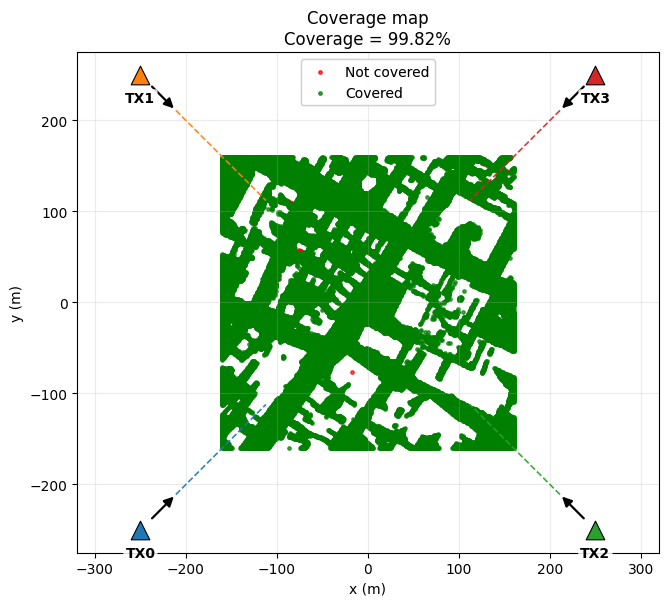

[OK] Saved config row -> snapshots/cfgA_config.parquet
Power List: [46, 46, 46, 46]
rx_power_coverage_ratio: 99.82%
SINR_mean: 21.89983097200086
Prx_p5_dBm: -49.376251220703125
total_tx_power_watt: 159.24286822139894


In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch


def dBm_to_watt(P_tx_dBm: float) -> float:
    return 10 ** ((P_tx_dBm - 30.0) / 10.0)

def rx_power_dBm(H, P_tx_dBm):
    """
    P_tx_dBm: total BS transmit power (dBm)
    H: [num_ue, num_rx_ant, num_tx_ant, num_sc]
    """
    gain = np.sum(np.abs(H)**2, axis=(1,2,3)) * N_sub
    return float(P_tx_dBm) + 10*np.log10(gain + 1e-30)

def kpi_stats(x):
    x = np.asarray(x)
    return {
        "min": float(np.min(x)),
        "p5": float(np.percentile(x, 5)),
        "median": float(np.median(x)),
        "mean": float(np.mean(x)),
        "max": float(np.max(x)),
    }

def serving_percentages(serving_tx, n_tx=4):
    counts = np.bincount(np.asarray(serving_tx, dtype=int), minlength=n_tx)
    K = len(serving_tx)
    return 100.0 * counts / max(K, 1)

def coverage_ratio(powers, thr, direction="ge"):
    powers = np.asarray(powers)
    mask_valid = np.isfinite(powers)
    powers = powers[mask_valid]
    n_total = powers.size

    if direction == "ge":
        mask = (powers >= thr)
    elif direction == "gt":
        mask = (powers > thr)
    elif direction == "le":
        mask = (powers <= thr)
    elif direction == "lt":
        mask = (powers < thr)
    else:
        raise ValueError("direction must be one of: ge, gt, le, lt")

    n_cov = int(np.sum(mask))
    return n_cov / n_total, n_cov


def set_bs_rotation(ch_params, base_rot_deg_list, d_az=0.0, d_el=0.0, d_pol=0.0):
    """
    rotation = [pol, el, az] in degrees
    """
    base_rot_deg = np.asarray(base_rot_deg_list, dtype=float)
    new_rot = base_rot_deg + np.array([d_pol, d_el, d_az], dtype=float)
    ch_params.bs_antenna.rotation = new_rot


def compute_kpis_full_ues(
    dataset_full,
    P_tx_dBm_list,
    BW,
    NF_dB=7.0,
    N0_dBm_perHz=-174.0,
    active_tx_mask=None
):

    K = dataset_full[0].rx_pos.shape[0]

    if active_tx_mask is None:
        active_tx_mask = [True, True, True, True]
    active_tx_mask = np.asarray(active_tx_mask, dtype=bool)
    if not np.any(active_tx_mask):
        raise ValueError("All TXs are OFF. At least one TX must be active.")

    # noise (mW) over BW
    noise_dBm = N0_dBm_perHz + 10*np.log10(BW) + NF_dB
    noise_mW  = 10**(noise_dBm/10)

    H = [dataset_full[i].channel for i in range(4)]

    # Prx per TX (K,4)
    Prx_dBm = np.stack([rx_power_dBm(H[i], float(P_tx_dBm_list[i])) for i in range(4)], axis=1)

    # exclude OFF TX from association
    Prx_dBm[:, ~active_tx_mask] = -np.inf

    # linear powers (mW)
    Prx_mW = np.zeros_like(Prx_dBm, dtype=float)
    active_cols = np.where(active_tx_mask)[0]
    Prx_mW[:, active_cols] = 10**(Prx_dBm[:, active_cols]/10)

    # best-cell association
    serving_tx = np.argmax(Prx_dBm, axis=1)
    rx_power_serv_dBm = Prx_dBm[np.arange(K), serving_tx]

    # SINR
    sig = Prx_mW[np.arange(K), serving_tx]
    intf = np.sum(Prx_mW, axis=1) - sig
    sinr_lin = sig / (intf + noise_mW)
    SINR_dB = 10*np.log10(sinr_lin + 1e-30)

    # RSSI = signal + interference + noise
    rssi_mW = sig + intf + noise_mW
    RSSI_dBm = 10*np.log10(rssi_mW + 1e-30)

    # throughput (Shannon)
    thr_Mbps = (BW * np.log2(1 + sinr_lin)) / 1e6

    # RR equal sharing within each serving TX
    n_users_per_tx = np.bincount(serving_tx, minlength=Prx_mW.shape[1])
    share = 1.0 / np.maximum(n_users_per_tx[serving_tx], 1)
    thr_rr_Mbps = thr_Mbps * share

    return serving_tx, rx_power_serv_dBm, SINR_dB, thr_Mbps, thr_rr_Mbps, RSSI_dBm


def add_txs_with_beam_legend(
    ax,
    dataset_dm,
    base_rot_list,
    deltas_list,
    P_list_raw,
    arrow_len=35.0,
    beam_len=120.0,
    gap=12.0,
    marker_size=160,
    tx_colors=None,
    beam_style="--",
    tx_label_dy=-18,
):

    if tx_colors is None:
        tx_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

    for i in range(4):
        tx = np.array(dataset_dm[i].tx_pos).reshape(-1)
        tx_x, tx_y = float(tx[0]), float(tx[1])

        dAz, _ = deltas_list[i]
        P_val = P_list_raw[i]
        is_on = (P_val is not None)

        if is_on:
            face = tx_colors[i]
            label = f"TX{i}"
            alpha_marker = 1.0
        else:
            face = "lightgray"
            label = f"TX{i}\nOFF"
            alpha_marker = 0.8

        ax.scatter(
            tx_x, tx_y,
            s=marker_size,
            marker="^",
            facecolor=face,
            edgecolor="k",
            linewidth=0.8,
            alpha=alpha_marker,
            zorder=10
        )

        ax.text(
            tx_x, tx_y + tx_label_dy,
            label,
            ha="center",
            va="top",
            fontsize=10,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85),
            zorder=12
        )

        if not is_on:
            continue

        # yön: base_az + dAz
        base_az = float(np.asarray(base_rot_list[i], dtype=float)[2])
        az_dir_deg = base_az + float(dAz)

        th = np.deg2rad(az_dir_deg)
        ux, uy = np.cos(th), np.sin(th)

        x0 = tx_x + gap * ux
        y0 = tx_y + gap * uy
        x1 = tx_x + (gap + arrow_len) * ux
        y1 = tx_y + (gap + arrow_len) * uy

        arrow = FancyArrowPatch(
            (x0, y0), (x1, y1),
            arrowstyle="-|>",
            mutation_scale=14,
            linewidth=1.6,
            color="k",
            zorder=11
        )
        ax.add_patch(arrow)

        bx1 = x1 + beam_len * ux
        by1 = y1 + beam_len * uy
        ax.plot(
            [x1, bx1], [y1, by1],
            linestyle=beam_style,
            linewidth=1.2,
            color=tx_colors[i],
            alpha=0.9,
            zorder=9
        )


def build_config_row_from_arrays(
    active_tx_mask,
    total_tx_power_watt,
    P_list_raw,
    deltas_list,
    coverage_threshold_dBm,
    serving_tx,
    prx_serv_dBm,
    sinr_dB,
    thr_Mbps,
    thr_rr_Mbps,
    rssi_dBm
):
    rx_power_cov_ratio, rx_power_cov_n = coverage_ratio(prx_serv_dBm, coverage_threshold_dBm, "ge")
    K = len(prx_serv_dBm)
    rx_power_out_n = int(K - rx_power_cov_n)

    prx_s = kpi_stats(prx_serv_dBm)
    sinr_s = kpi_stats(sinr_dB)
    thr_s = kpi_stats(thr_Mbps)
    thr_rr_s = kpi_stats(thr_rr_Mbps)
    rssi_s = kpi_stats(rssi_dBm)

    serve_pct = serving_percentages(serving_tx, n_tx=4)

    row = {
        "tx0_on": bool(active_tx_mask[0]),
        "tx1_on": bool(active_tx_mask[1]),
        "tx2_on": bool(active_tx_mask[2]),
        "tx3_on": bool(active_tx_mask[3]),

        "total_tx_power_watt": float(total_tx_power_watt),

        "tx0_P_dBm": (-9999.0 if P_list_raw[0] is None else float(P_list_raw[0])),
        "tx1_P_dBm": (-9999.0 if P_list_raw[1] is None else float(P_list_raw[1])),
        "tx2_P_dBm": (-9999.0 if P_list_raw[2] is None else float(P_list_raw[2])),
        "tx3_P_dBm": (-9999.0 if P_list_raw[3] is None else float(P_list_raw[3])),

        "tx0_served_pct": float(serve_pct[0]),
        "tx1_served_pct": float(serve_pct[1]),
        "tx2_served_pct": float(serve_pct[2]),
        "tx3_served_pct": float(serve_pct[3]),

        "tx0_dAz": float(deltas_list[0][0]), "tx0_dEl": float(deltas_list[0][1]),
        "tx1_dAz": float(deltas_list[1][0]), "tx1_dEl": float(deltas_list[1][1]),
        "tx2_dAz": float(deltas_list[2][0]), "tx2_dEl": float(deltas_list[2][1]),
        "tx3_dAz": float(deltas_list[3][0]), "tx3_dEl": float(deltas_list[3][1]),

        "Prx_min_dBm": prx_s["min"],
        "Prx_p5_dBm": prx_s["p5"],
        "Prx_median_dBm": prx_s["median"],
        "Prx_mean_dBm": prx_s["mean"],
        "Prx_max_dBm": prx_s["max"],

        "SINR_min_dB": sinr_s["min"],
        "SINR_p5_dB": sinr_s["p5"],
        "SINR_median_dB": sinr_s["median"],
        "SINR_mean_dB": sinr_s["mean"],
        "SINR_max_dB": sinr_s["max"],

        "Thr_min_Mbps": thr_s["min"],
        "Thr_p5_Mbps": thr_s["p5"],
        "Thr_median_Mbps": thr_s["median"],
        "Thr_mean_Mbps": thr_s["mean"],
        "Thr_max_Mbps": thr_s["max"],

        "ThrRR_min_Mbps": thr_rr_s["min"],
        "ThrRR_p5_Mbps": thr_rr_s["p5"],
        "ThrRR_median_Mbps": thr_rr_s["median"],
        "ThrRR_mean_Mbps": thr_rr_s["mean"],
        "ThrRR_max_Mbps": thr_rr_s["max"],

        "RSSI_min_dBm": rssi_s["min"],
        "RSSI_p5_dBm": rssi_s["p5"],
        "RSSI_median_dBm": rssi_s["median"],
        "RSSI_mean_dBm": rssi_s["mean"],
        "RSSI_max_dBm": rssi_s["max"],

        "rx_power_thr_dBm": float(coverage_threshold_dBm),
        "rx_power_coverage_ratio": float(rx_power_cov_ratio),
        "rx_power_cov_n": int(rx_power_cov_n),
        "rx_power_out_n": int(rx_power_out_n),
    }
    return row


def plot_and_store_one_config(
    dataset_dm,
    ch_params_list,
    base_rot_list,
    deltas_list,
    P_list_raw,
    coverage_threshold_dBm,
    BW,
    NF_dB=7.0,
    N0_dBm_perHz=-174.0,
    s=6,
    save_dir=None,     # örn: "snapshots"
    tag=None,          # örn: "cfgA"  -> cfgA_config.parquet
):
    # active mask
    active_tx_mask = [p is not None for p in P_list_raw]
    if not any(active_tx_mask):
        raise ValueError("All TXs are OFF for this configuration.")

    # P list for KPI compute (dummy for OFF)
    P_list = [(-1000.0 if p is None else float(p)) for p in P_list_raw]
    total_tx_power_watt = float(sum(dBm_to_watt(p) for p in P_list))

    # 1) set rotations + compute channels
    for i in range(4):
        d_az, d_el = deltas_list[i]
        set_bs_rotation(ch_params_list[i], base_rot_list[i], d_az=d_az, d_el=d_el, d_pol=0.0)
        dataset_dm[i].compute_channels(ch_params_list[i])

    # 2) compute KPIs
    serving_tx, prx_serv_dBm, sinr_dB, thr_Mbps, thr_rr_Mbps, rssi_dBm = compute_kpis_full_ues(
        dataset_full=dataset_dm,
        P_tx_dBm_list=P_list,
        BW=BW,
        NF_dB=NF_dB,
        N0_dBm_perHz=N0_dBm_perHz,
        active_tx_mask=active_tx_mask
    )

    covered = prx_serv_dBm >= float(coverage_threshold_dBm)

    # receiver positions
    xy = dataset_dm[0].rx_pos[:, :2]
    x = xy[:, 0]
    y = xy[:, 1]

    n_cov = int(np.sum(covered))
    K = len(covered)
    covered_pct = 100 * n_cov / K
    print(f"Coverage: {covered_pct:.2f}%  ({n_cov}/{K})")

    # 3) plot
    fig, ax = plt.subplots(figsize=(7.5, 6.5))

    h_not = ax.scatter(x[~covered], y[~covered], s=s, c="red", alpha=0.7, label="Not covered")
    h_cov = ax.scatter(x[covered],  y[covered],  s=s, c="green", alpha=0.7, label="Covered")

    cov_leg = ax.legend(handles=[h_not, h_cov], loc="upper center")
    ax.add_artist(cov_leg)

    add_txs_with_beam_legend(
        ax=ax,
        dataset_dm=dataset_dm,
        base_rot_list=base_rot_list,
        deltas_list=deltas_list,
        P_list_raw=P_list_raw,
        arrow_len=40.0,
        beam_len=140,
        gap=15,
        marker_size=180
    )

    ax.set_title(f"Coverage map\nCoverage = {covered_pct:.2f}%")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.axis("equal")
    ax.grid(True, alpha=0.25)
    plt.show()

    # 4) build config row (generator columns)
    config_row = build_config_row_from_arrays(
        active_tx_mask=active_tx_mask,
        total_tx_power_watt=total_tx_power_watt,
        P_list_raw=P_list_raw,
        deltas_list=deltas_list,
        coverage_threshold_dBm=float(coverage_threshold_dBm),
        serving_tx=serving_tx,
        prx_serv_dBm=prx_serv_dBm,
        sinr_dB=sinr_dB,
        thr_Mbps=thr_Mbps,
        thr_rr_Mbps=thr_rr_Mbps,
        rssi_dBm=rssi_dBm
    )

    # 5) save config parquet
    saved_path = None
    if save_dir is not None and tag is not None:
        os.makedirs(save_dir, exist_ok=True)
        saved_path = os.path.join(save_dir, f"{tag}_config.parquet")
        pd.DataFrame([config_row]).to_parquet(saved_path, index=False)
        print(f"[OK] Saved config row -> {saved_path}")

    return {
        "config_row": config_row,
        "saved_path": saved_path,
        "covered": covered,
        "serving_tx": serving_tx,
        "prx_serv_dBm": prx_serv_dBm,
        "sinr_dB": sinr_dB,
        "thr_Mbps": thr_Mbps,
        "thr_rr_Mbps": thr_rr_Mbps,
        "rssi_dBm": rssi_dBm
    }


# Example usage
#sıralama = [TX0, TX1, TX2, TX3]
#deltas_list = [(dAz,dEl)]
#P_list_raw  = [40, 40, None, 40]   None for off

deltas_list = [(0,0), (0,0), (0,0), (0,0)]
P_list_raw  = [46, 46, 46, 46]
out = plot_and_store_one_config(
     dataset_dm=dataset_dm,
     ch_params_list=ch_params_list,
     base_rot_list=base_rot_list,
     deltas_list=deltas_list,
     P_list_raw=P_list_raw,
     coverage_threshold_dBm=-60,
     BW=BW,
     NF_dB=7.0,
     N0_dBm_perHz=-174.0,
     s=6,
     save_dir="snapshots",
     tag="cfgA"
 )
pd.DataFrame([out["config_row"]])
print(f"Power List: {P_list_raw}")
print(f"rx_power_coverage_ratio: {out['config_row']['rx_power_coverage_ratio']*100:.2f}%")
print(f"SINR_mean: {out["config_row"]["SINR_mean_dB"]}" )
print(f"Prx_p5_dBm: {out["config_row"]["Prx_p5_dBm"]}" )
print(f"total_tx_power_watt: {out["config_row"]["total_tx_power_watt"]}" )

In [ ]:
out["config_row"]["SINR_mean_dB"]

-0.07889670674032147

In [ ]:
out["config_row"]["Prx_p5_dBm"]

-257.0000305175781